In [1]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n = [2, 4, 6, 10, 20, 50, 100, 200]

p_notaveis = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

p = sorted(set(np.round(np.arange(0.05, 1.0, 0.05), 2).tolist() + p_notaveis))

regras_k = {
    "k=1": lambda n: 1,
    "k=n/2": lambda n: n // 2,
    "k=n": lambda n: n,
}

def calcular_probabilidade_sistema_disponivel(n: int, k: int, p: float) -> float:
    soma = sum(math.comb(n, i) * (p ** i) * (1 - p) ** (n - i) for i in range(0, k))
    return (1 - soma)

linhas = []
for ni in n:
    ks_vistos = set()
    for nome_k, regra_k in regras_k.items():
        ki = regra_k(ni)
        if ki in ks_vistos:
            continue
        ks_vistos.add(ki)
        for pi in p:
            resultado = calcular_probabilidade_sistema_disponivel(ni, ki, pi)
            linhas.append((ni, ki, pi, resultado))

tabela = pd.DataFrame(linhas, columns=["n", "k", "p", "Resultado"])
pd.set_option("display.float_format", "{:.10f}".format)

display(tabela)

,n,k,p,Resultado
0,2,1,0.0500000000,0.0975000000
1,2,1,0.1000000000,0.1900000000
2,2,1,0.1500000000,0.2775000000
3,2,1,0.2000000000,0.3600000000
4,2,1,0.2500000000,0.4375000000
...,...,...,...,...
455,200,200,0.8000000000,0.0000000000
456,200,200,0.8500000000,0.0000000000
457,200,200,0.9000000000,0.0000000007
458,200,200,0.9500000000,0.0000350527


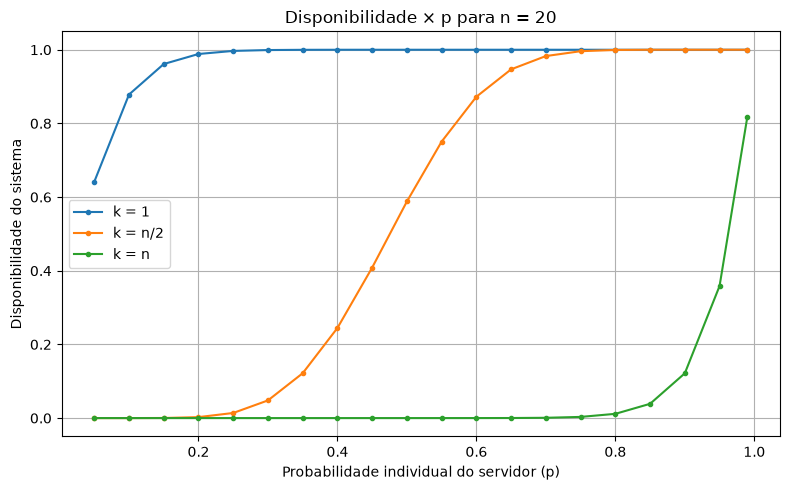

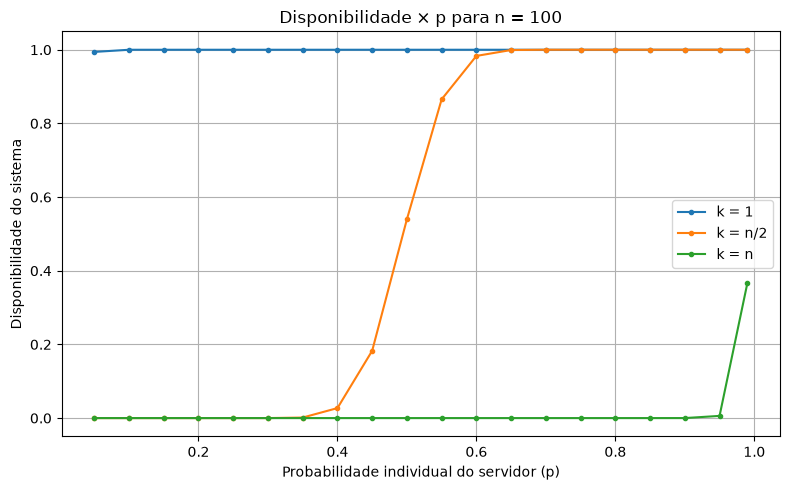

In [3]:
## Disponibilidade × p

def plotar_disponibilidade_vs_p(tabela: pd.DataFrame, n_alvo: int) -> None:
    dados = tabela[tabela["n"] == n_alvo]

    plt.figure(figsize=(8, 5))
    for ki in sorted(dados["k"].unique()):
        if ki == 1:
            rotulo = "k = 1"
        elif ki == n_alvo:
            rotulo = "k = n"
        elif ki == n_alvo // 2:
            rotulo = "k = n/2"
        else:
            rotulo = f"k = {ki}"
        dados_k = dados[dados["k"] == ki]
        plt.plot(dados_k["p"], dados_k["Resultado"], marker="o", markersize=3, label=rotulo)

    plt.xlabel("Probabilidade individual do servidor (p)")
    plt.ylabel("Disponibilidade do sistema")
    plt.title(f"Disponibilidade × p para n = {n_alvo}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

plotar_disponibilidade_vs_p(tabela, n_alvo=20)
plotar_disponibilidade_vs_p(tabela, n_alvo=100)

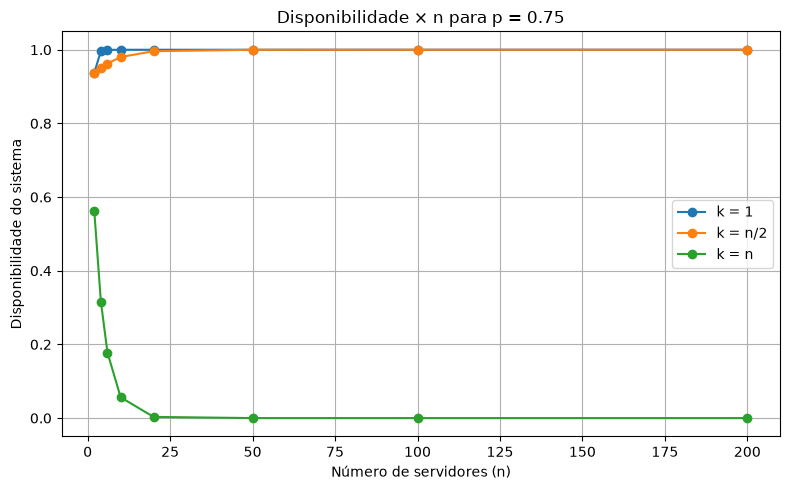

In [4]:
## Disponibilidade × n

def plotar_disponibilidade_vs_n(tabela: pd.DataFrame, p_alvo: float) -> None:
    dados = tabela[np.isclose(tabela["p"], p_alvo)]
    dados_k1 = dados[dados["k"] == 1]
    dados_k_metade = dados[dados["k"] == dados["n"] // 2]
    dados_kn = dados[dados["k"] == dados["n"]]

    plt.figure(figsize=(8, 5))
    plt.plot(dados_k1["n"], dados_k1["Resultado"], marker="o", label="k = 1")
    plt.plot(dados_k_metade["n"], dados_k_metade["Resultado"], marker="o", label="k = n/2")
    plt.plot(dados_kn["n"], dados_kn["Resultado"], marker="o", label="k = n")

    plt.xlabel("Número de servidores (n)")
    plt.ylabel("Disponibilidade do sistema")
    plt.title(f"Disponibilidade × n para p = {p_alvo}")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

plotar_disponibilidade_vs_n(tabela, p_alvo=0.75)

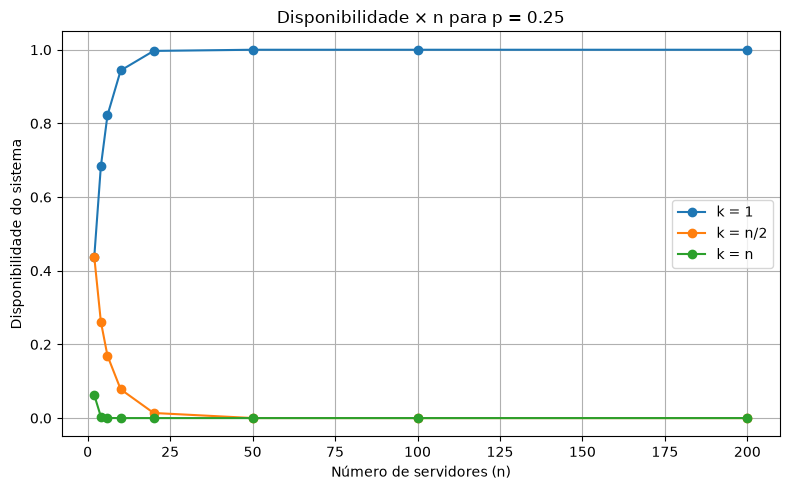

In [5]:
plotar_disponibilidade_vs_n(tabela, p_alvo=0.25)

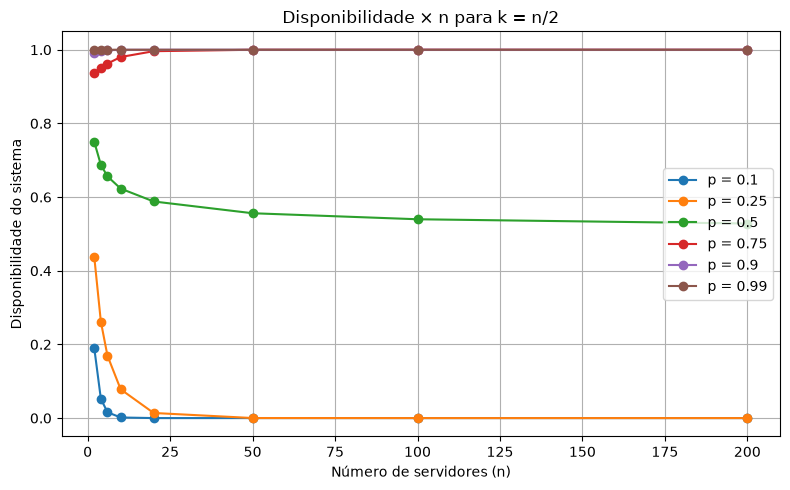

In [6]:
dados = tabela[tabela["k"] == tabela["n"] // 2]

plt.figure(figsize=(8, 5))

for pi in p_notaveis:
    dados_p = dados[np.isclose(dados["p"], pi)]
    plt.plot(dados_p["n"], dados_p["Resultado"], marker="o", label=f"p = {pi}")

plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title("Disponibilidade × n para k = n/2")

plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

# Parte 2: Simulador estocástico

Para uma combinação de `n`, `k` e `p`, geramos um número de rodadas escolhido pelo usuário. Em cada rodada, sorteamos a disponibilidade de cada servidor individualmente (um número aleatório entre 0 e 1, comparado a `p`), contamos quantos servidores ficaram disponíveis e verificamos se o serviço permaneceu operacional (pelo menos `k` disponíveis). A frequência experimental é a proporção de rodadas bem-sucedidas, que comparamos com o valor obtido pela fórmula (Parte 1) no gráfico de convergência logo abaixo.

In [7]:
rng = np.random.default_rng(42)

def simular_disponibilidade(n: int, k: int, p: float, num_rodadas: int = 10_000) -> float:
    disponiveis = rng.random((num_rodadas, n)) <= p
    servidores_disponiveis = disponiveis.sum(axis=1)
    sucessos = servidores_disponiveis >= k
    return sucessos.mean()

## Gráfico de convergência: valor experimental × valor analítico conforme o número de rodadas

O número de rodadas é o que controla o quão perto o simulador chega do valor analítico: com poucas rodadas, o erro amostral domina. Em vez de rodar o simulador uma única vez com um número de rodadas fixo e muito alto, o gráfico mostra a frequência experimental para uma grade de quantidades de rodadas espaçadas em escala logarítmica, comparando-a com o valor analítico (linha tracejada). Isso deixa a convergência visível diretamente no gráfico.

Os parâmetros abaixo (`N_CONVERGENCIA`, `K_CONVERGENCIA`, `P_CONVERGENCIA`, `RODADAS_MIN`, `RODADAS_MAX`, `RODADAS_PONTOS`) foram isolados numa célula própria para serem fáceis de alterar e testar outros cenários sem precisar mexer no código da função de plotagem.

In [8]:
# Parâmetros do gráfico de convergência

N_CONVERGENCIA = 20      # número de servidores
K_CONVERGENCIA = 10      # quórum mínimo de servidores disponíveis
P_CONVERGENCIA = 0.5     # probabilidade individual de cada servidor estar disponível

RODADAS_MIN = 10         # menor número de rodadas testado
RODADAS_MAX = 20_000     # maior número de rodadas testado
RODADAS_PONTOS = 25      # quantidade de pontos na grade (granularidade do gráfico)

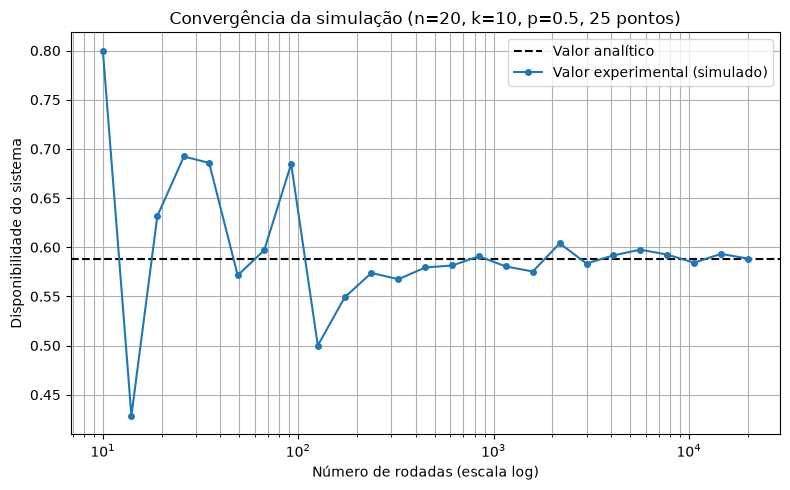

In [9]:
def gerar_grade_rodadas(rodadas_min: int, rodadas_max: int, pontos: int) -> list[int]:
    return sorted(set(np.round(np.geomspace(rodadas_min, rodadas_max, pontos)).astype(int)))

def plotar_convergencia(n: int, k: int, p: float, rodadas_min: int, rodadas_max: int, pontos: int) -> None:
    rodadas_testadas = gerar_grade_rodadas(rodadas_min, rodadas_max, pontos)
    analitico = calcular_probabilidade_sistema_disponivel(n, k, p)
    experimentais = [simular_disponibilidade(n, k, p, r) for r in rodadas_testadas]

    plt.figure(figsize=(8, 5))
    plt.axhline(analitico, color="black", linestyle="--", label="Valor analítico")
    plt.plot(rodadas_testadas, experimentais, marker="o", markersize=4, label="Valor experimental (simulado)")

    plt.xscale("log")
    plt.xlabel("Número de rodadas (escala log)")
    plt.ylabel("Disponibilidade do sistema")
    plt.title(f"Convergência da simulação (n={n}, k={k}, p={p}, {pontos} pontos)")
    plt.legend()
    plt.grid(which="both")
    plt.tight_layout()
    plt.show()

plotar_convergencia(
    N_CONVERGENCIA, K_CONVERGENCIA, P_CONVERGENCIA,
    RODADAS_MIN, RODADAS_MAX, RODADAS_PONTOS,
)

O mesmo cenário com o dobro de pontos na grade de rodadas (mesmo intervalo, mais granularidade), para uma curva ainda mais suave:

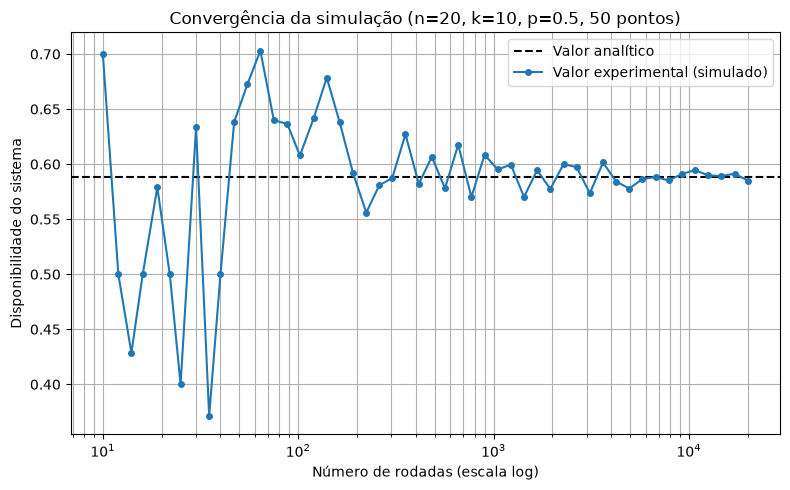

In [10]:
plotar_convergencia(
    N_CONVERGENCIA, K_CONVERGENCIA, P_CONVERGENCIA,
    RODADAS_MIN, RODADAS_MAX, pontos=RODADAS_PONTOS * 2,
)